In [1]:
import numpy as np
import glob
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
from oaatutils import *

In [10]:
def add_lab(ax,c,dx=0.08,dy=0.05):
    x1,x2=ax.get_xlim()
    y1,y2=ax.get_ylim()
    ax.text(x1+dx*(x2-x1),
            y1+dy*(y2-y1),
            '('+c+')',ha='center',va='center')

In [3]:
f='../postp/oaat_postp.nc'
ds=xr.open_dataset(f)

In [4]:
df=pd.read_csv('cats.csv')
cats=np.unique(df.cat.values)
cols={cat:df.color[df.cat==cat].values[0] for cat in cats}

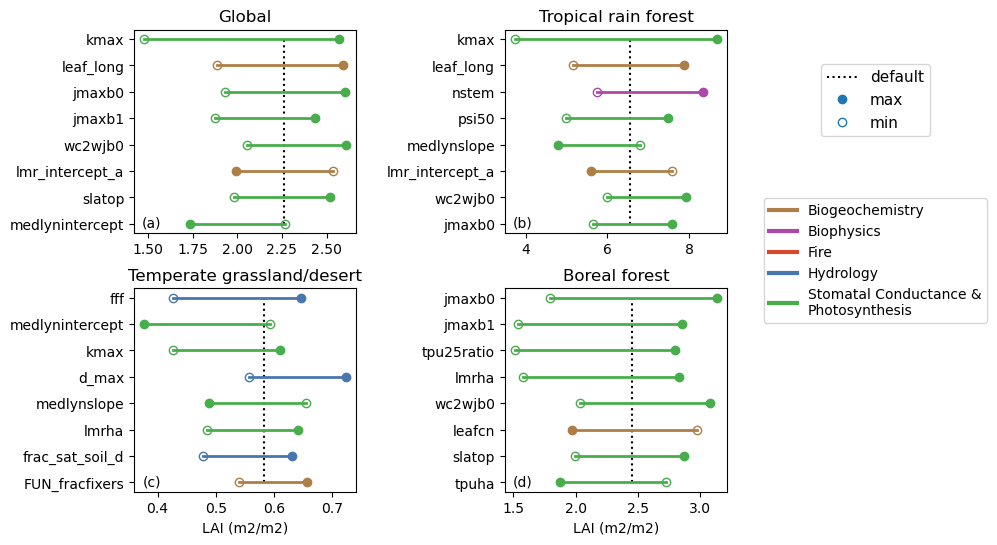

In [11]:
fig,axs=plt.subplot_mosaic('AXBF;AXBE;GXHE;CXDE;CXDI',
                           figsize=[11,6],
                           gridspec_kw={'width_ratios': [3,1,3,3],'height_ratios': [3, 1,0.5,1,3]})
for s in 'XEFGHI':
    axs[s].axis('off')


da=ds.TLAI_global_mean.sel(exp='CTL2010')
rank_plot(da,8,ax=axs['A'])
axs['A'].set_title('Global')
for b,s in zip([1,7,8],'BCD'):
    da=ds.TLAI_biome_mean.sel(exp='CTL2010',biome=b)
    rank_plot(da,8,ax=axs[s])
    axs[s].set_title(ds.biome_name[b].values)
    if b>1:
        axs[s].set_xlabel('LAI (m2/m2)')

for s in 'ABCD':
    add_lab(axs[s],s.lower())


axs['F'].plot([1,1],[1,1],'k:',label='default')
axs['F'].plot([1,1],[1,1],'C0o',label='max')
axs['F'].plot([1,1],[1,1],'C0o',label='min',fillstyle='none')
axs['F'].set_ylim([100,101])
axs['F'].legend(fontsize=11,loc=10)
for cat in cats:
    axs['E'].plot([1,1],[1,1],lw=3,color=cols[cat],label=cat)
axs['E'].legend(loc=10)

plt.savefig('../figs/main/lai_biome.pdf',bbox_inches='tight')